In [105]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
import seaborn as sns
import itertools
import joblib
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

In [232]:
df = pd.read_csv('harga_beras_2021_2025.csv')
df['tanggal'] = pd.to_datetime(df['tanggal'])

In [233]:
df.head()

,tanggal,tahun,bulan,lebaran,harga_beras,harga_gkg,curah_hujan,produksi_padi,inflasi_pangan
0,2021-01-01,2021,1,0,11000.0,5317.84,357.44,34832.38,0.71
1,2021-02-01,2021,2,0,11000.0,5319.55,667.13,120453.56,0.62
2,2021-03-01,2021,3,0,11000.0,5213.95,217.58,101075.88,0.38
3,2021-04-01,2021,4,0,10900.0,4882.22,173.56,51600.05,-0.22
4,2021-05-01,2021,5,1,10750.0,4944.18,130.15,31423.12,-0.17


In [234]:
# 2. Feature Engineering: Lags and Rolling Mean
df['lag_1'] = df['harga_beras'].shift(1)
df['lag_2'] = df['harga_beras'].shift(2)

df['rolling_mean_3'] = df['harga_beras'].rolling(window=3).mean()

In [235]:
df.head()

,tanggal,tahun,bulan,lebaran,harga_beras,harga_gkg,curah_hujan,produksi_padi,inflasi_pangan,lag_1,lag_2,rolling_mean_3
0,2021-01-01,2021,1,0,11000.0,5317.84,357.44,34832.38,0.71,NaN,NaN,NaN
1,2021-02-01,2021,2,0,11000.0,5319.55,667.13,120453.56,0.62,11000.0,NaN,NaN
2,2021-03-01,2021,3,0,11000.0,5213.95,217.58,101075.88,0.38,11000.0,11000.0,11000.000000
3,2021-04-01,2021,4,0,10900.0,4882.22,173.56,51600.05,-0.22,11000.0,11000.0,10966.666667
4,2021-05-01,2021,5,1,10750.0,4944.18,130.15,31423.12,-0.17,10900.0,11000.0,10883.333333


In [236]:
# Drop rows that have NaN values because of the shift()/rolling()
# (Because of lag_6, the first 6 months of 2021 will be dropped)
features_to_check = ['lag_1', 'lag_2', 'rolling_mean_3']

In [237]:
df = df.dropna(subset=features_to_check).copy()

In [238]:
df.count()

tanggal           57
tahun             57
bulan             57
lebaran           57
harga_beras       57
harga_gkg         57
curah_hujan       57
produksi_padi     57
inflasi_pangan    57
lag_1             57
lag_2             57
rolling_mean_3    57
dtype: int64

In [239]:
# 3. Train-Test Split (Train: 2021-2024, Test: 2025)
train_df = df[df['tanggal'].dt.year <= 2024].copy()
test_df = df[df['tanggal'].dt.year == 2025].copy()

In [240]:
# 4. Prepare data for Prophet
prophet_train = train_df[['tanggal', 'harga_beras', 'lebaran']].rename(columns={'tanggal': 'ds', 'harga_beras': 'y'})
prophet_test = test_df[['tanggal', 'harga_beras', 'lebaran']].rename(columns={'tanggal': 'ds', 'harga_beras': 'y'})


In [241]:
# 5. Initialize and Fit Prophet on TRAIN data only
model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model_prophet.add_regressor('lebaran')
model_prophet.fit(prophet_train)

23:40:49 - cmdstanpy - INFO - Chain [1] start processing


23:40:50 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
# # 6. Predict on Train and Test sets
# forecast_train = model_prophet.predict(prophet_train[['ds', 'lebaran']])
# forecast_test = model_prophet.predict(prophet_test[['ds', 'lebaran']])

In [242]:
# 2. Predict on the ENTIRE dataset to get seamless residuals
# We use the original 'df' here to keep the timeline connected
prophet_full = df[['tanggal', 'lebaran']].rename(columns={'tanggal': 'ds'})
forecast_full = model_prophet.predict(prophet_full)

In [243]:
# 3. Calculate full timeline residuals
df['yhat'] = forecast_full['yhat'].values
df['residual'] = df['harga_beras'] - df['yhat']

In [244]:
# 4. Feature Engineering: Create Residual Lags!
df['residual_lag_1'] = df['residual'].shift(1)
df['residual_lag_2'] = df['residual'].shift(2)

In [245]:
# Drop the first 2 rows of the entire dataset that became NaN due to shifting
df = df.dropna(subset=['residual_lag_1', 'residual_lag_2']).copy()

In [252]:
# 5. NOW split back into Train and Test for XGBoost
train_df = df[df['tanggal'].dt.year <= 2024].copy()
test_df = df[df['tanggal'].dt.year == 2025].copy()
print(f"Ready for XGBoost! Train size: {train_df.shape}, Test size: {test_df.shape}")

Ready for XGBoost! Train size: (44, 17), Test size: (11, 17)


In [57]:
# # 7. Add predictions (yhat) and calculate residuals (Actual - yhat)
# train_df['yhat'] = forecast_train['yhat'].values
# train_df['residual'] = train_df['harga_beras'] - train_df['yhat']
# test_df['yhat'] = forecast_test['yhat'].values
# test_df['residual'] = test_df['harga_beras'] - test_df['yhat']
# print(f"Training data shape (2021-2024): {train_df.shape}")
# print(f"Testing data shape (2025): {test_df.shape}")

In [247]:
# Evaluation Metrics on the Test Set (2025)
mae_test = mean_absolute_error(test_df['harga_beras'], test_df['yhat'])
mape_test = mean_absolute_percentage_error(test_df['harga_beras'], test_df['yhat'])
rmse_test = root_mean_squared_error(test_df['harga_beras'], test_df['yhat'])
print("--- PROPHET TEST SET EVALUATION (2025) ---")
print(f"Test MAE: {mae_test:.2f}")
print(f"Test MAPE: {mape_test:.2%}")
print(f"Test RMSE: {rmse_test:.2f}")
print("-" * 40)


--- PROPHET TEST SET EVALUATION (2025) ---
Test MAE: 423.71
Test MAPE: 2.99%
Test RMSE: 462.15
----------------------------------------


In [59]:
joblib.dump(model_prophet, 'prophet_model.pkl')

['prophet_model.pkl']

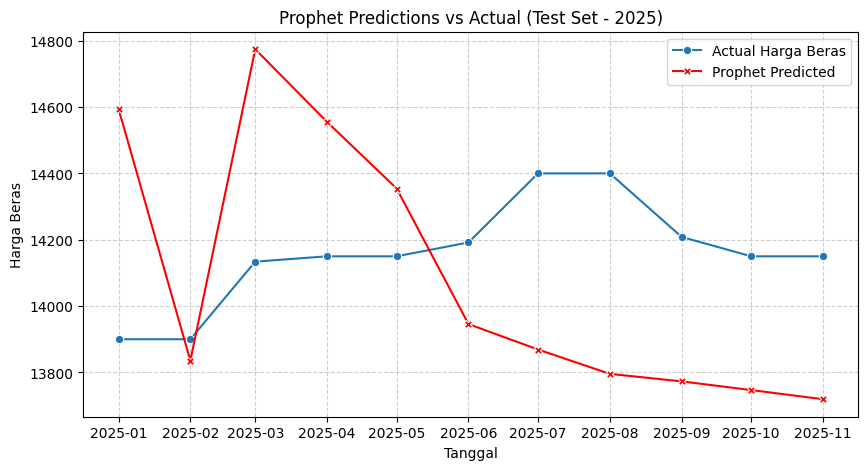

In [248]:
# Visualization of Actual vs Predicted (Test Set)
plt.figure(figsize=(10, 5))
sns.lineplot(x=test_df['tanggal'], y=test_df['harga_beras'], label='Actual Harga Beras', marker='o')
sns.lineplot(x=test_df['tanggal'], y=test_df['yhat'], label='Prophet Predicted', marker='X', color='red')
plt.title('Prophet Predictions vs Actual (Test Set - 2025)')
plt.ylabel('Harga Beras')
plt.xlabel('Tanggal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# TUNING PROPHET

In [196]:
# 1. Define the Parameter Grid
param_grid = {  
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.1, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative']
}

# Generate all combinations of parameters (4 x 3 x 2 = 24 combinations)
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
results = []
print(f"Starting Prophet Grid Search: {len(all_params)} combinations to try...")

Starting Prophet Grid Search: 24 combinations to try...


In [ ]:
# 2. Loop through each combination
for i, params in enumerate(all_params):
    print(f"Testing combination {i+1}/{len(all_params)}: {params}")
    try:
        m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, **params)
        m.add_regressor('lebaran')
        m.fit(prophet_train)
        
        # Cross Validation
        df_cv = cross_validation(m, initial='730 days', period='90 days', horizon='180 days')
        df_p = performance_metrics(df_cv, rolling_window=1)
        
        # Store parameters and results together safely
        res = params.copy()
        res['rmse'] = df_p['rmse'].values[0]
        res['mape'] = df_p['mape'].values[0]
        results.append(res)
        
    except Exception as e:
        print(f"  -> Failed for parameters {params}: {e}")


In [198]:
# 3. Compile and Sort Results
if len(results) > 0:
    tuning_results = pd.DataFrame(results)
    tuning_results = tuning_results.sort_values(by='mape').reset_index(drop=True)
    print("\n--- TOP 5 PROPHET PARAMETER COMBINATIONS ---")
    print(tuning_results.head(5))
    best_prophet_params = tuning_results.iloc[0].drop(['rmse', 'mape']).to_dict()
    print(f"\nBest Prophet Parameters Found:\n{best_prophet_params}")
else:
    print("No combinations were successfully evaluated. Please check your training data.")


--- TOP 5 PROPHET PARAMETER COMBINATIONS ---
   changepoint_prior_scale  seasonality_prior_scale seasonality_mode  \
0                     0.05                      1.0   multiplicative   
1                     0.10                      0.1   multiplicative   
2                     0.01                      0.1   multiplicative   
3                     0.01                      0.1         additive   
4                     0.50                      0.1   multiplicative   

          rmse      mape  
0   859.322165  0.050671  
1   921.141143  0.052236  
2   859.848511  0.056980  
3   866.224621  0.057210  
4  1119.594675  0.058660  

Best Prophet Parameters Found:
{'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative'}


In [61]:
# print("\nRunning Prophet Cross Validation...")
# # initial='730 days' (2 years train), period='90 days' (shift 3 months), horizon='180 days' (predict 6 months)
# df_cv = cross_validation(model_prophet, initial='730 days', period='90 days', horizon='180 days')
# df_p = performance_metrics(df_cv)
# print("\nCross Validation Performance Metrics:")

# print(df_p.head())


In [62]:
# # Custom plot to avoid the Prophet/Pandas bug
# plt.figure(figsize=(10, 5))
# # Convert the horizon to integer days for the x-axis
# horizon_days = df_p['horizon'].dt.days
# # Plot the MAPE from the performance metrics dataframe
# plt.plot(horizon_days, df_p['mape'], marker='o', color='blue', linewidth=2)
# plt.title('Cross-Validation MAPE over Time')
# plt.xlabel('Forecast Horizon (Days)')
# plt.ylabel('Mean Absolute Percentage Error (MAPE)')
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.show()

In [63]:
# # 8. Save the Prophet Model
# joblib.dump(model_prophet, 'prophet_model.pkl')
# print("\nModel successfully saved to 'prophet_model.joblib'")

In [64]:
# Show the results with our new features and residuals!
# train_df[['tanggal', 'harga_beras', 'yhat', 'residual', 'lag_1', 'lag_2', 'rolling_mean_3']].head()

In [249]:
# 1. Extract the month from the 'tanggal' column (if you don't already have a 'bulan' column)
df['month'] = df['tanggal'].dt.month
# 2. Apply Sine and Cosine transformations
# We use 12 because there are 12 months in a cyclical year
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [250]:
# 3. Drop the 'month' column (and the original 'bulan' column if it exists)
# errors='ignore' ensures it won't crash if the 'bulan' column isn't there
df = df.drop(columns=['month', 'bulan'], errors='ignore')

In [251]:
df.head()

,tanggal,tahun,lebaran,harga_beras,harga_gkg,curah_hujan,produksi_padi,inflasi_pangan,lag_1,lag_2,rolling_mean_3,yhat,residual,residual_lag_1,residual_lag_2,month_sin,month_cos
4,2021-05-01,2021,1,10750.0,4944.18,130.15,31423.12,-0.17,10900.0,11000.0,10883.333333,10954.780290,-204.780290,-104.568572,-69.852005,5.000000e-01,-8.660254e-01
5,2021-06-01,2021,0,10750.0,4963.86,186.10,65810.96,-0.32,10750.0,10900.0,10800.000000,10590.843680,159.156320,-204.780290,-104.568572,1.224647e-16,-1.000000e+00
6,2021-07-01,2021,0,10750.0,4873.89,21.88,56962.41,0.36,10750.0,10750.0,10750.000000,10610.430669,139.569331,159.156320,-204.780290,-5.000000e-01,-8.660254e-01
7,2021-08-01,2021,0,10750.0,5038.23,78.86,30706.60,0.02,10750.0,10750.0,10750.000000,10636.295449,113.704551,139.569331,159.156320,-8.660254e-01,-5.000000e-01
8,2021-09-01,2021,0,10750.0,5047.91,166.60,11898.06,1.01,10750.0,10750.0,10750.000000,10712.971817,37.028183,113.704551,139.569331,-1.000000e+00,-1.836970e-16


# REGRESSION XGBOOST

In [253]:
# 1. Define Features and Target for XGBoost
features = [
    'harga_gkg', 
    'curah_hujan', 
    'produksi_padi', 
    'inflasi_pangan', 
    'lag_1', 
    'lag_2', 
    'rolling_mean_3',
    'residual_lag_1',
    'residual_lag_2',
    'month_sin',
    'month_cos'
]
# The target is the error Prophet left behind
target = 'residual'
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

In [254]:
# 2. Initialize and Train XGBoost
# These are standard baseline hyperparameters you can tune later
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
print("Training XGBoost on Prophet's residuals...")
xgb_model.fit(X_train, y_train)

Training XGBoost on Prophet's residuals...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [255]:
# 3. Predict the residuals using XGBoost
train_df['xgb_pred_residual'] = xgb_model.predict(X_train)
test_df['xgb_pred_residual'] = xgb_model.predict(X_test)

In [256]:
# 4. Create the final Hybrid Prediction 
# Hybrid Forecast = Prophet Forecast + XGBoost Residual Forecast
train_df['hybrid_pred'] = train_df['yhat'] + train_df['xgb_pred_residual']
test_df['hybrid_pred'] = test_df['yhat'] + test_df['xgb_pred_residual']


In [257]:
# 5. Evaluate the Hybrid Model on the Test Set (2025)
mae_hybrid = mean_absolute_error(test_df['harga_beras'], test_df['hybrid_pred'])
mape_hybrid = mean_absolute_percentage_error(test_df['harga_beras'], test_df['hybrid_pred'])
rmse_hybrid = root_mean_squared_error(test_df['harga_beras'], test_df['hybrid_pred'])

print("\n--- HYBRID MODEL TEST SET EVALUATION (2025) ---")
print(f"Test MAE: {mae_hybrid:.2f}")
print(f"Test MAPE: {mape_hybrid:.2%}")
print(f"Test RMSE: {rmse_hybrid:.2f}")
print("-" * 45)


--- HYBRID MODEL TEST SET EVALUATION (2025) ---
Test MAE: 395.36
Test MAPE: 2.79%
Test RMSE: 433.63
---------------------------------------------


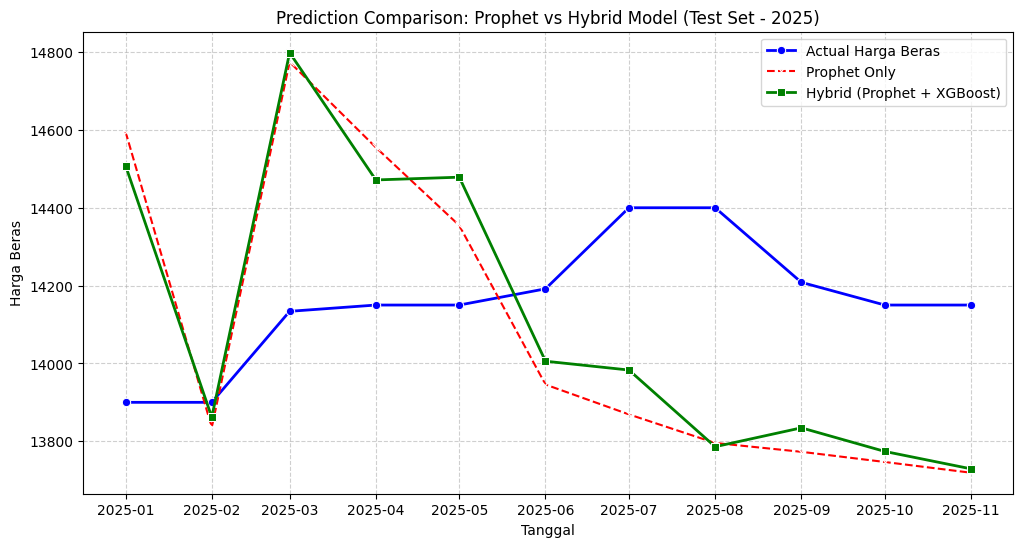

In [258]:
# 6. Visualization: Compare Actual vs Prophet vs Hybrid
plt.figure(figsize=(12, 6))
# Plot Hybrid Data
sns.lineplot(x=test_df['tanggal'], y=test_df['harga_beras'], label='Actual Harga Beras', marker='o', color='blue', linewidth=2)
sns.lineplot(x=test_df['tanggal'], y=test_df['yhat'], label='Prophet Only', marker='x', color='red', linestyle='--')
sns.lineplot(x=test_df['tanggal'], y=test_df['hybrid_pred'], label='Hybrid (Prophet + XGBoost)', marker='s', color='green', linewidth=2)
plt.title('Prediction Comparison: Prophet vs Hybrid Model (Test Set - 2025)')
plt.ylabel('Harga Beras')
plt.xlabel('Tanggal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# HYPERPARAMETER TUNING

In [259]:
# 1. Define the Hyperparameter Grid to search through
param_grid = {
    'n_estimators': [30, 50, 80, 100],          # Keep tree count low
    'learning_rate': [0.05, 0.1, 0.15],         # Moderate learning rates
    'max_depth': [2, 3, 4],                     # Shallow trees are crucial here!
    'subsample': [0.5, 0.7, 0.8],               # High dropout to force generalization
    'colsample_bytree': [0.5, 0.7, 0.8],        # High feature dropout
    'min_child_weight': [1, 3, 5]               # Require more data to make a split
}

In [260]:
# 2. Setup TimeSeriesSplit
# This ensures cross-validation only ever trains on the past to predict the future
tscv = TimeSeriesSplit(n_splits=3)

In [261]:
# 3. Initialize the base XGBoost model
xgb_base = XGBRegressor(random_state=42)

In [262]:
# 4. Setup RandomizedSearchCV
# n_iter=30 means it will test 30 random combinations of the parameters above
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=30, 
    scoring='neg_mean_absolute_error',
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
print("Starting Hyperparameter Tuning for XGBoost...")

Starting Hyperparameter Tuning for XGBoost...


In [263]:
# 5. Fit the search on the Training Residuals
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.5, 0.7, ...], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [2, 3, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies

In [264]:
# 6. Extract the best model and print its parameters
best_xgb_model = random_search.best_estimator_
print("-" * 40)
print(f"Best Hyperparameters found:\n{random_search.best_params_}")
print("-" * 40)

----------------------------------------
Best Hyperparameters found:
{'subsample': 0.5, 'n_estimators': 50, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
----------------------------------------


In [265]:
# 7. Predict using the TUNED model
train_df['tuned_xgb_residual'] = best_xgb_model.predict(X_train)
test_df['tuned_xgb_residual'] = best_xgb_model.predict(X_test)
# Calculate the new Tuned Hybrid Prediction
train_df['tuned_hybrid_pred'] = train_df['yhat'] + train_df['tuned_xgb_residual']
test_df['tuned_hybrid_pred'] = test_df['yhat'] + test_df['tuned_xgb_residual']

In [266]:
# 8. Evaluate the Tuned Model on the Test Set (2025)
tuned_mae = mean_absolute_error(test_df['harga_beras'], test_df['tuned_hybrid_pred'])
tuned_mape = mean_absolute_percentage_error(test_df['harga_beras'], test_df['tuned_hybrid_pred'])
tuned_rmse = root_mean_squared_error(test_df['harga_beras'], test_df['tuned_hybrid_pred'])
print("\n--- TUNED HYBRID MODEL TEST SET EVALUATION (2025) ---")
print(f"Tuned Test MAE: {tuned_mae:.2f}")
print(f"Tuned Test MAPE: {tuned_mape:.2%}")
print(f"Tuned Test RMSE: {tuned_rmse:.2f}")


--- TUNED HYBRID MODEL TEST SET EVALUATION (2025) ---
Tuned Test MAE: 388.73
Tuned Test MAPE: 2.74%
Tuned Test RMSE: 436.86


In [267]:
joblib.dump(best_xgb_model, 'best_xgb_model.pkl')

['best_xgb_model.pkl']

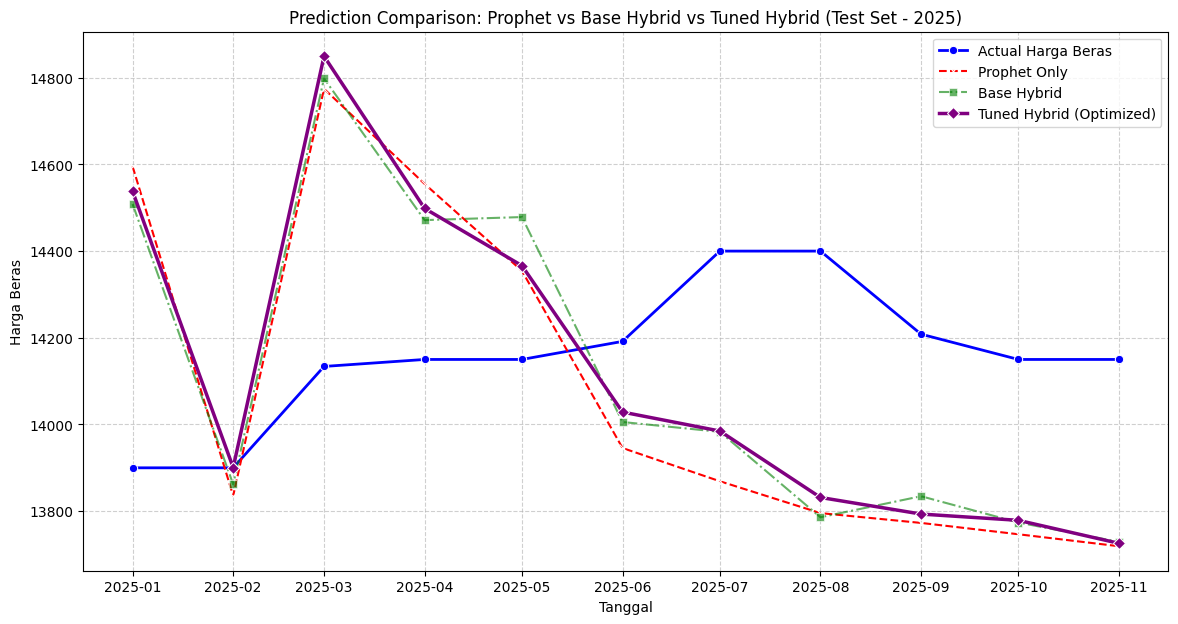

In [97]:
# Visualization: Compare Actual vs Prophet vs Base Hybrid vs Tuned Hybrid
plt.figure(figsize=(14, 7))
# Plot Actual Data
sns.lineplot(x=test_df['tanggal'], y=test_df['harga_beras'], label='Actual Harga Beras', marker='o', color='blue', linewidth=2)
# Plot Prophet Only Data
sns.lineplot(x=test_df['tanggal'], y=test_df['yhat'], label='Prophet Only', marker='x', color='red', linestyle='--')
# Plot Base Hybrid Data
sns.lineplot(x=test_df['tanggal'], y=test_df['hybrid_pred'], label='Base Hybrid', marker='s', color='green', linestyle='-.', alpha=0.6)
# Plot TUNED Hybrid Data
sns.lineplot(x=test_df['tanggal'], y=test_df['tuned_hybrid_pred'], label='Tuned Hybrid (Optimized)', marker='D', color='purple', linewidth=2.5)
plt.title('Prediction Comparison: Prophet vs Base Hybrid vs Tuned Hybrid (Test Set - 2025)')
plt.ylabel('Harga Beras')
plt.xlabel('Tanggal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best')
plt.show()

# RECURSIVE FORECASTING

In [98]:
print("Starting Recursive Forecasting for 2025...")
# 1. We need a fresh copy of the test set to manipulate during the loop
recursive_test_df = test_df.copy().reset_index(drop=True)
# 2. We need the actual history from the training set to "kickstart" the first few lags
# We will append our predictions to these lists as we move forward in time
history_harga_beras = list(train_df['harga_beras'].values)
history_residuals = list(train_df['residual'].values)
recursive_predictions = []

Starting Recursive Forecasting for 2025...


In [99]:
# 3. Loop through each month in the 2025 test set one by one
for i in range(len(recursive_test_df)):
    # Get the current month's row (which has the correct dates and exogenous variables)
    row = recursive_test_df.iloc[[i]].copy()
    
    # --- UPDATE FEATURES USING OUR OWN PREDICTIONS ---
    row['lag_1'] = history_harga_beras[-1]
    row['lag_2'] = history_harga_beras[-2]
    row['lag_3'] = history_harga_beras[-3]
    row['lag_6'] = history_harga_beras[-6]
    
    # Update rolling features based on our predicted history
    row['rolling_mean_3'] = np.mean(history_harga_beras[-3:])
    # ddof=1 for sample standard deviation to match Pandas default
    row['rolling_std_3'] = np.std(history_harga_beras[-3:], ddof=1) 
    row['rolling_mean_6'] = np.mean(history_harga_beras[-6:])
    
    # Update residual lags based on XGBoost's previous error predictions
    row['residual_lag_1'] = history_residuals[-1]
    row['residual_lag_2'] = history_residuals[-2]
    
    # --- MAKE THE PREDICTION ---
    # Predict the residual using XGBoost with the newly updated features
    X_current = row[features]
    
    # Use the best_xgb_model if you did hyperparameter tuning, otherwise use xgb_model
    predicted_residual = best_xgb_model.predict(X_current)[0] 
    
    # Prophet's yhat is already calculated (it only relies on dates and exogenous vars)
    prophet_yhat = row['yhat'].values[0]
    
    # Final Hybrid Prediction = Prophet Trend + XGBoost Error Correction
    hybrid_prediction = prophet_yhat + predicted_residual
    
    # --- STORE RESULTS ---
    recursive_predictions.append(hybrid_prediction)
    
    # Append the prediction to the history so the NEXT loop step can use it as a lag!
    history_harga_beras.append(hybrid_prediction)
    history_residuals.append(predicted_residual)
# Add the recursive predictions back to the dataframe
recursive_test_df['recursive_hybrid_pred'] = recursive_predictions


In [100]:
# 4. Evaluate the Recursive Model
rec_mae = mean_absolute_error(recursive_test_df['harga_beras'], recursive_test_df['recursive_hybrid_pred'])
rec_mape = mean_absolute_percentage_error(recursive_test_df['harga_beras'], recursive_test_df['recursive_hybrid_pred'])
rec_rmse = root_mean_squared_error(recursive_test_df['harga_beras'], recursive_test_df['recursive_hybrid_pred'])
print("\n--- RECURSIVE HYBRID EVALUATION (2025) ---")
print(f"Recursive MAE: {rec_mae:.2f}")
print(f"Recursive MAPE: {rec_mape:.2%}")
print(f"Recursive RMSE: {rec_rmse:.2f}")



--- RECURSIVE HYBRID EVALUATION (2025) ---
Recursive MAE: 419.16
Recursive MAPE: 2.96%
Recursive RMSE: 463.76


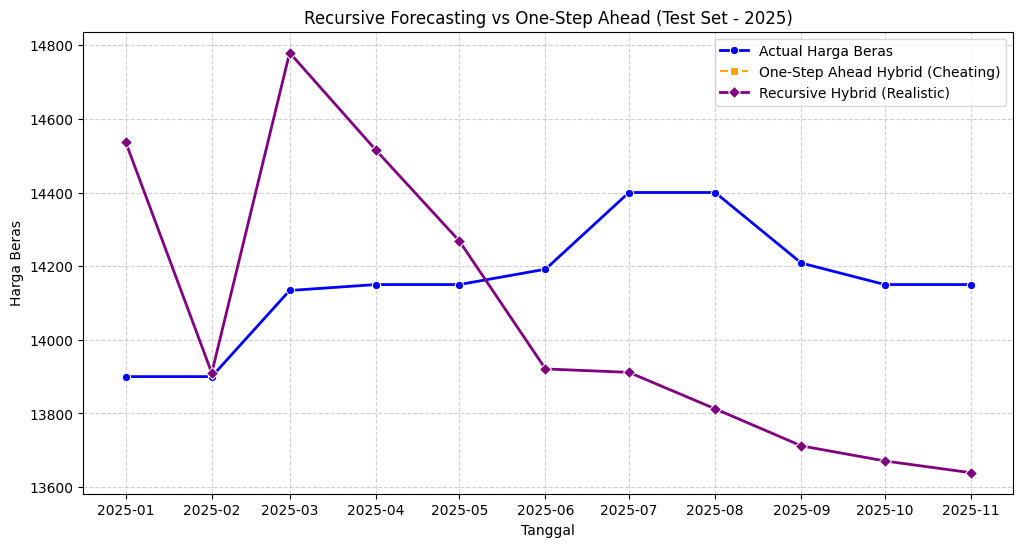

In [101]:
# 5. Visualize it!
plt.figure(figsize=(12, 6))
sns.lineplot(x=recursive_test_df['tanggal'], y=recursive_test_df['harga_beras'], label='Actual Harga Beras', marker='o', color='blue', linewidth=2)
sns.lineplot(x=recursive_test_df['tanggal'], y=test_df['tuned_hybrid_pred'], label='One-Step Ahead Hybrid (Cheating)', marker='s', color='orange', linestyle='--')
sns.lineplot(x=recursive_test_df['tanggal'], y=recursive_test_df['recursive_hybrid_pred'], label='Recursive Hybrid (Realistic)', marker='D', color='purple', linewidth=2)
plt.title('Recursive Forecasting vs One-Step Ahead (Test Set - 2025)')
plt.ylabel('Harga Beras')
plt.xlabel('Tanggal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# FEATURE IMPORTANCE

In [102]:
# 1. Extract the feature importances from the trained model
# Note: If you didn't use hyperparameter tuning, change 'best_xgb_model' to 'xgb_model'
importances = best_xgb_model.feature_importances_
# 2. Create a Pandas DataFrame matching the feature names to their importance scores
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})
# 3. Sort the DataFrame from most important to least important
importance_df = importance_df.sort_values(by='Importance', ascending=False)

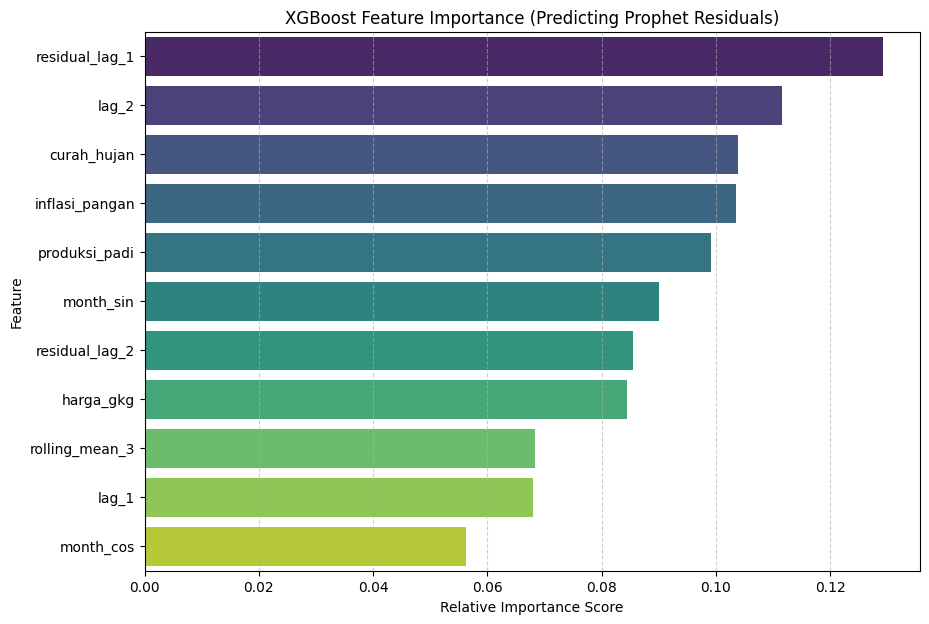

In [103]:
# 4. Plot it!
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('XGBoost Feature Importance (Predicting Prophet Residuals)')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [104]:
# Print the exact numbers
print("--- EXACT IMPORTANCE SCORES ---")
print(importance_df.to_string(index=False))

--- EXACT IMPORTANCE SCORES ---
       Feature  Importance
residual_lag_1    0.129198
         lag_2    0.111634
   curah_hujan    0.103843
inflasi_pangan    0.103563
 produksi_padi    0.099179
     month_sin    0.090088
residual_lag_2    0.085465
     harga_gkg    0.084437
rolling_mean_3    0.068357
         lag_1    0.067923
     month_cos    0.056313
